# STEM with abTEM 1.0.6
Run cells in order. The scan cells are deliberately separate; inspect the planned position count and detector-angle warnings before running them. No simulation starts on import.

In [1]:
from config import Config
from modules.atomic_model import build_atomic_model, show_projections, print_transform
from modules.potential import build_potential, show_potential
from modules.wave_function import build_probe, show_probe
from modules.scan_detector import configure_scan, show_scan_and_detectors, run_annular_scan, run_4d_scan
from modules.postprocessing import process_measurements

config = Config()
# Edit config fields here before prepare_output() if needed.
run_dir = config.prepare_output()
print('Input:', config.input_cif)
print('Output:', run_dir)


Input: /data/home/wy_zhoushengmin/python_projects/abTEM/STEM_abTEM/data/input/PbS.cif
Output: /data/home/wy_zhoushengmin/python_projects/abTEM/STEM_abTEM/data/output/PbS/001/20260930_160020_472739


## 1. Atomic model
The configured (hkl) plane normal is rotated onto the beam z axis. Orthogonalization and repetition use a copy of the CIF structure.

Atoms: 32 PBC: [True, True, True]
Cell (Å): [[8.46101432, 0.0, 0.0], [0.0, 11.9649896, 0.0], [0.0, 0.0, 8.43319393]]
Euler angles (degrees): 	 x = 0.000, 	 y = 0.000, 	 z = 0.000
Normal strains (percent): 	 x = 0.000, 	 y = 0.000, 	 z = 0.000
Shear strains (percent): 	 xy = 0.000, 	 xz = 0.000, 	 xz = 0.000


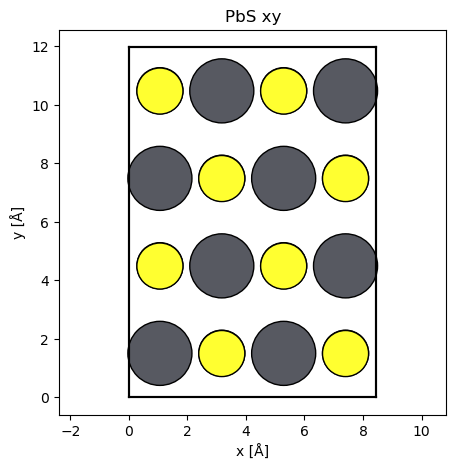

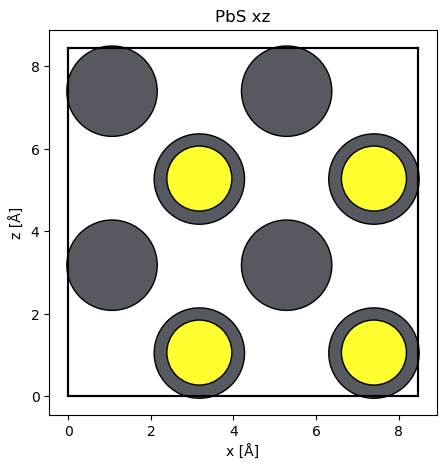

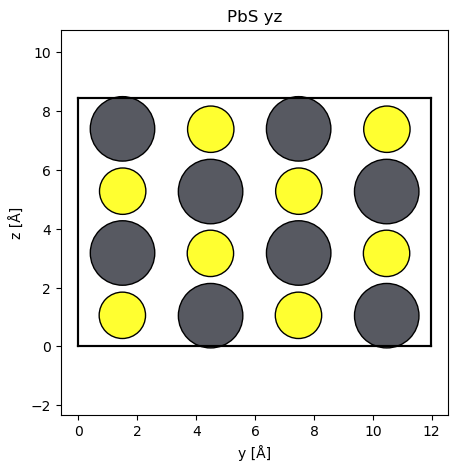

In [2]:
atoms_ortho, atomic_metadata = build_atomic_model(config)
config.save_metadata('atomic_model', atomic_metadata)
print('Atoms:', atomic_metadata['atom_count'], 'PBC:', atomic_metadata['pbc'])
print('Cell (Å):', atomic_metadata['final_cell_A'])
print_transform(atomic_metadata)
atomic_figures = show_projections(atoms_ortho, config)


## 2. Potential
Plotting the projection and first slices materializes only the requested diagnostic arrays.

Potential slices: 9
[########################################] | 100% Completed | 1.28 ss


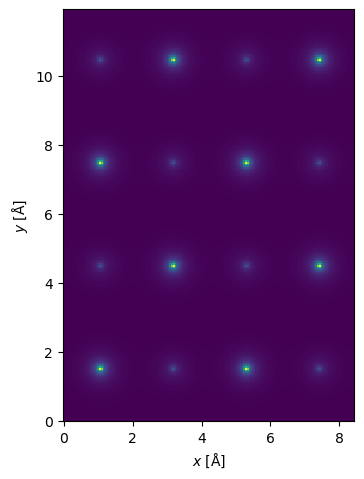

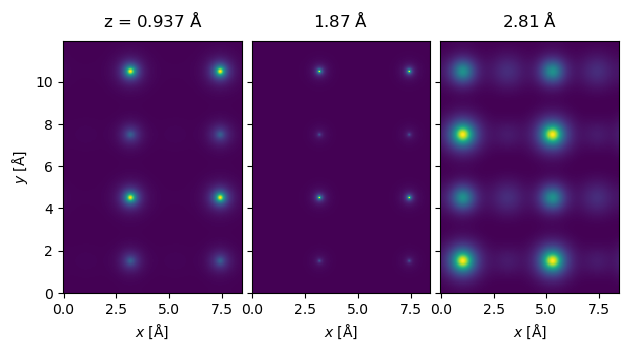

In [3]:
potential, potential_metadata = build_potential(atoms_ortho, config)
config.save_metadata('potential', potential_metadata)
print('Potential slices:', potential_metadata['num_slices'])
projected, first_slices = show_potential(potential, config)


## 3. Probe
The red reciprocal-space circle is the incident probe aperture. It does not bound scattering from the sample. The potential grid takes precedence over optional Probe grid inputs.

Effective probe grid: (170, 240) (0.04977067247058824, 0.049854123333333326) Å
[########################################] | 100% Completed | 207.36 ms


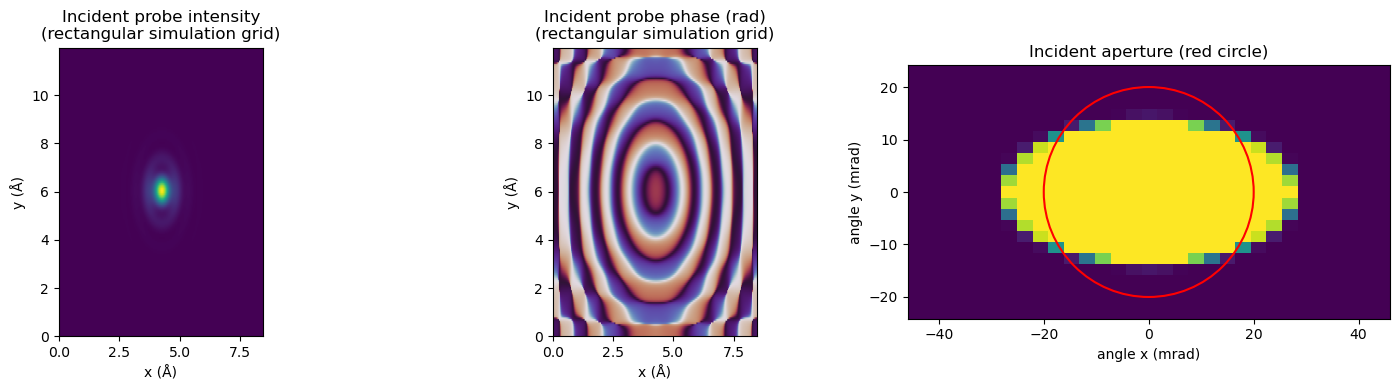

In [4]:
probe, waves, probe_metadata = build_probe(potential, config)
config.save_metadata('probe', probe_metadata)
print('Effective probe grid:', probe_metadata['effective_gpts'], probe_metadata['effective_sampling_A'], 'Å')
probe_figure = show_probe(waves, config)


## 4. Detectors and scan grid
Check the reported number of positions and any high-angle warnings. BF, MAADF, and HAADF ranges intentionally retain their configured overlap.

Antialias cutoff: 167.7 mrad (current probe sampling 0.0498 Å); detector angles above this are not quantitatively supported.
To support 200.0 mrad approximately, use potential sampling_A <= 0.0417 Å (this increases the simulation grid size).
Manual STEM scan: 27 × 39 = 1053 positions; step 0.313 Å


/tmp/ipykernel_812263/1876054148.py:1: UserWarning: HAADF outer angle 200.0 mrad exceeds antialias cutoff 167.7 mrad; high-angle signal may be invalid.
  scan, detectors, pixel_detector, scan_metadata = configure_scan(potential, probe, atoms_ortho, config)


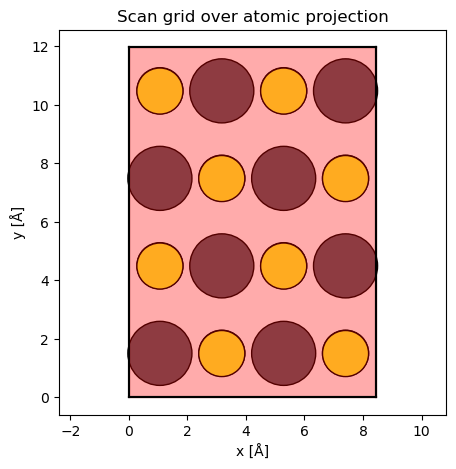

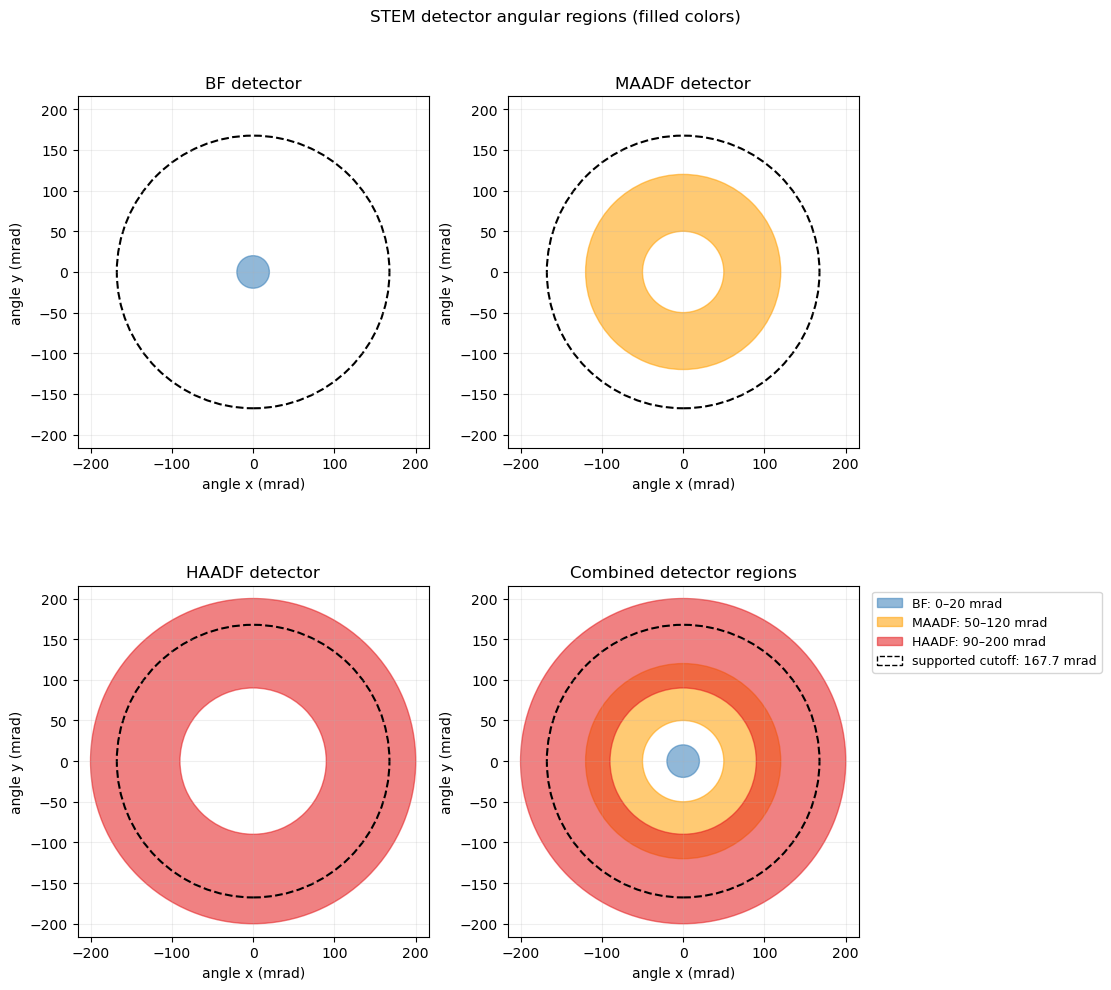

In [5]:
scan, detectors, pixel_detector, scan_metadata = configure_scan(potential, probe, atoms_ortho, config)
config.save_metadata('scan_detector', scan_metadata)
scan_figures = show_scan_and_detectors(scan, detectors, atoms_ortho, probe, config)


## 5. Manual small annular STEM scan
Execute this cell when ready. All three annular signals are computed together with a visible progress indicator and saved as raw Zarr measurements.

[########################################] | 100% Completed | 11.58 s
[########################################] | 100% Completed | 101.58 ms
[########################################] | 100% Completed | 101.57 ms
[########################################] | 100% Completed | 101.65 ms
Saved raw BF, MAADF, HAADF measurements in /data/home/wy_zhoushengmin/python_projects/abTEM/STEM_abTEM/data/output/PbS/001/20260930_160020_472739/measurements


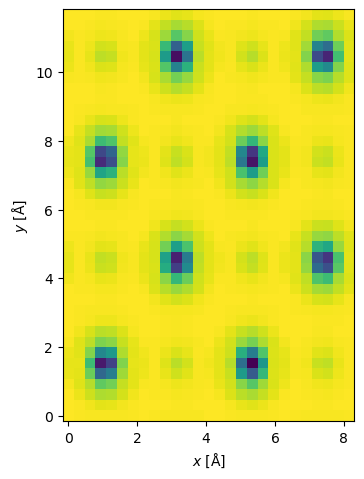

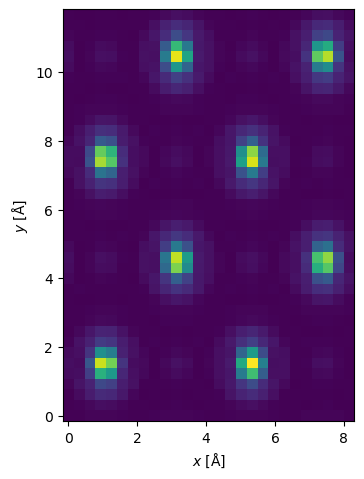

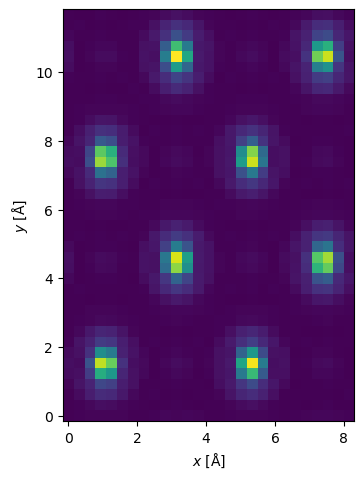

In [6]:
measurements = run_annular_scan(probe, potential, scan, detectors, config)
print('Saved raw BF, MAADF, HAADF measurements in', run_dir / 'measurements')


## 6. Optional image postprocessing
Set `config.postprocessing.enabled = True` before executing this cell. The saved stages keep raw, interpolated, blurred, and quantitative Poisson-noisy measurements separate.

In [7]:
if config.postprocessing.enabled:
    config.prepare_output()  # refresh effective configuration after interactive edits
    stages, postprocessing_metadata = process_measurements(measurements, config)
    config.save_metadata('postprocessing', postprocessing_metadata)
else:
    print('Postprocessing disabled.')


Postprocessing disabled.


## 7. Optional 4D-STEM
Set `config.detector.enable_4d_stem = True` before the first cell and rerun setup stages. This cell then performs a separate pixelated scan and writes raw chunked Zarr data. The detector is never created when the switch is off.

In [8]:
if config.detector.enable_4d_stem:
    pixelated = run_4d_scan(probe, potential, scan, pixel_detector, config)
    print('Saved raw pixelated diffraction data in', run_dir / '4d_stem')
else:
    print('4D-STEM disabled; no pixelated data created.')


4D-STEM disabled; no pixelated data created.
